In [1]:
import pyzx_env.pyZX_env_zx as env
import pyzx as zx
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
e = env.pyZX_env(15,500)

obs, _ = e.reset()
state, action_masks, state_zx_graph, node_masks, edge_masks, rule_mask = obs
print("state",state)
print("action_mask",action_masks.shape)
print("action_mask",action_masks[:,-4:])
print("state_zx_graph",state_zx_graph)
print("zx type",type(state_zx_graph), zx.settings.drawing_backend)
print("node_mask",node_masks.shape)
print("edge_masks",edge_masks.shape)
print("rule_mask",rule_mask.shape)
print(state_zx_graph.edges())
G=nx.from_edgelist(state_zx_graph.edges())
print(np.mean(list(nx.eccentricity(G).values())))
zx.draw(state_zx_graph,)

state Data(x=[578, 2], edge_index=[2, 1222], edge_attr=[1222])
action_mask (8, 1801)
action_mask [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
state_zx_graph Graph(578 vertices, 611 edges)
zx type <class 'pyzx.graph.graph_s.GraphS'> d3
node_mask (8, 578)
edge_masks (8, 1222)
rule_mask (8,)
<generator object GraphS.edges at 0x7f21848c10e0>
37.1159169550173


In [2]:
state_zx_graph.graph[0]

{18: 1}

In [3]:
import numpy as np
import torch
from utils import mask_to_index
print(mask_to_index(torch.tensor(action_masks.T)))
i = np.argmax(action_masks[:,7])
[state,action_masks, state_zx_graph, node_masks, edge_masks, rule_mask], reward, term, trunc, info = e.step(i,7)
print("reward",reward)
zx.draw(state_zx_graph)

tensor([[  16,    3],
        [  16,    7],
        [  17,    3],
        ...,
        [1783,    1],
        [1785,    0],
        [1785,    1]])
reward -66


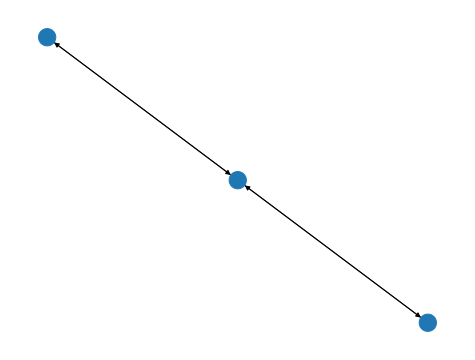

In [4]:
import utils
import torch
from torch_geometric.data import Data
import networkx as nx
import torch_geometric

edge_index = torch.tensor([[0, 1, 1, 2],
                        [1, 0, 2, 1]], dtype=torch.long)
x = torch.tensor([[-1], [0], [1]], dtype=torch.float)
edge_features=torch.tensor([10,20,30,40])
d = Data(x,edge_index=edge_index,edge_attr=edge_features)
old = torch_geometric.utils.to_networkx(d)
nx.draw(old)

Data(x=[1186, 2], edge_index=[2, 1218]) Data(x=[1795, 2], edge_index=[2, 2436])


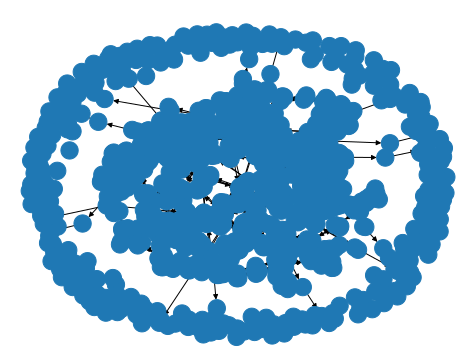

In [7]:
from utils import expand_graph
[state,action_masks, state_zx_graph, node_masks, edge_masks, rule_mask], info = e.reset()
s = Data(x=state.x,edge_index=state.edge_index[:,:state.edge_index.shape[1]//2],edge_attr=state.edge_attr[:state.edge_index.shape[1]//2])
#print(s,state)
exp = expand_graph(s)
e2 = expand_graph(state)
print(exp,e2)
new = torch_geometric.utils.to_networkx(exp,)
nx.draw(new)